## 0. Imports

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, precision_recall_curve,
                              average_precision_score, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), ".."))
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
RESULTS_DIR   = os.path.join(BASE_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

print("✅ Imports OK")


✅ Imports OK


## 1. Load analytical table

In [2]:
# Load from processed — built in Notebook 01
master_path = os.path.join(PROCESSED_DIR, "master_analytical.csv")

if os.path.exists(master_path):
    df = pd.read_csv(master_path, low_memory=False)
    print(f"✅ Loaded: {len(df):,} rows × {df.shape[1]} cols")
else:
    # Rebuild from raw if processed not found
    print("⚠️  master_analytical.csv not found — rebuilding from raw...")
    RAW_DIR = os.path.join(BASE_DIR, "data", "raw")

    import glob
    def find_file(name):
        matches = glob.glob(os.path.join(RAW_DIR, "**", name), recursive=True)
        return matches[0] if matches else None

    main      = pd.read_csv(find_file("main.csv"), low_memory=False)
    awards    = pd.read_csv(find_file("awards.csv"), low_memory=False)
    suppliers = pd.read_csv(find_file("awards_suppliers.csv"), low_memory=False)

    df = main.merge(
        awards[["main_ocid","value_amount","status"]].rename(
            columns={"value_amount":"award_value","status":"award_status"}),
        left_on="ocid", right_on="main_ocid", how="left"
    ).merge(
        suppliers[["main_ocid","name"]].rename(columns={"name":"supplier_name"}),
        left_on="ocid", right_on="main_ocid", how="left"
    )
    df["buyer_name"]    = df["buyer_name"].str.strip().str.upper()
    df["supplier_name"] = df["supplier_name"].str.strip().str.upper()
    print(f"✅ Rebuilt: {len(df):,} rows")


✅ Loaded: 37,823 rows × 43 cols


## 2. Build ground truth labels

### Labelling strategy
- **Label 1 (suspicious):** `direct`, `limited`, `selective` procurement methods
- **Label 0 (clean):** `open` procurement method
- **SIU Tembisa suppliers** included as additional label-1 if found in data

### Why procurement method is a valid proxy
In SA public procurement law, `direct` and `limited` awards legally require
written justification. They are the documented mechanism for single-source
corruption — including all Tembisa syndicate awards. Using them as labels
is not an assumption; it is legally grounded.


In [3]:
# ── Signal 1: Procurement method labels ──────────────────────────────────
SUSPICIOUS_METHODS = ["direct", "limited", "selective"]

df["label_method"] = df["tender_procurementMethod"].apply(
    lambda x: 1 if str(x).lower() in SUSPICIOUS_METHODS else 0
)

# ── Signal 2: Known SIU Tembisa syndicate suppliers ───────────────────────
# These are the documented family networks from the SIU Tembisa report
# Cross-referenced against our supplier names
TEMBISA_SYNDICATES = [
    "MAUMELA", "MAZIBUKO", "GOVINDRAJ", "GOVINDRAJU",
    "NTSHUXEKO", "RIRHANDZU", "PFANANANI", "MUKHACWA",
    "NTSAKO SERVICES",
]

tembisa_mask = df["supplier_name"].str.contains(
    "|".join(TEMBISA_SYNDICATES), case=False, na=False
)
df["label_tembisa"] = tembisa_mask.astype(int)

# ── Combined ground truth ─────────────────────────────────────────────────
df["label"] = ((df["label_method"] == 1) | (df["label_tembisa"] == 1)).astype(int)

# ── Report ────────────────────────────────────────────────────────────────
pos = df["label"].sum()
neg = (df["label"] == 0).sum()
total = len(df)
from_tembisa = df["label_tembisa"].sum()
from_method  = df["label_method"].sum()
overlap      = ((df["label_method"]==1) & (df["label_tembisa"]==1)).sum()

print("Ground truth label distribution:")
print(f"  Label 1 (suspicious): {pos:>8,}  ({100*pos/total:.2f}%)")
print(f"  Label 0 (clean):      {neg:>8,}  ({100*neg/total:.2f}%)")
print(f"  Total:                {total:>8,}")
print()
print("Label sources:")
print(f"  From procurement method (direct/limited/selective): {from_method:,}")
print(f"  From SIU Tembisa suppliers:                         {from_tembisa:,}")
print(f"  Overlap (both signals):                             {overlap:,}")
print(f"  Combined unique positives:                          {pos:,}")
print()
print(f"Class imbalance ratio: 1:{neg//pos if pos>0 else 'N/A'}")


Ground truth label distribution:
  Label 1 (suspicious):      418  (1.11%)
  Label 0 (clean):        37,405  (98.89%)
  Total:                  37,823

Label sources:
  From procurement method (direct/limited/selective): 407
  From SIU Tembisa suppliers:                         11
  Overlap (both signals):                             0
  Combined unique positives:                          418

Class imbalance ratio: 1:89


## 3. Text preparation

Filter to records with usable descriptions and prepare text for TF-IDF.


In [4]:
# Filter to records with descriptions > 50 chars
nlp_df = df[df["tender_description"].notna() &
            (df["tender_description"].str.len() > 50)].copy()

print(f"Records with usable descriptions: {len(nlp_df):,}")
print(f"  Suspicious (label=1): {nlp_df['label'].sum():,}")
print(f"  Clean     (label=0): {(nlp_df['label']==0).sum():,}")

# Text cleaning function
def clean_text(text):
    """Basic text normalisation for SA government procurement text."""
    import re
    text = str(text).lower().strip()
    text = re.sub(r'\s+', ' ', text)                    # collapse whitespace
    text = re.sub(r'[^a-z0-9\s/(),-]', ' ', text)       # keep alphanumeric + common punct
    text = re.sub(r'\b(pty|ltd|soc|npc|cc|inc)\b', '', text)  # remove company suffixes
    return text.strip()

nlp_df["text_clean"] = nlp_df["tender_description"].apply(clean_text)

# Show sample from each class
print("\nSample suspicious descriptions (label=1):")
for txt in nlp_df[nlp_df["label"]==1]["text_clean"].head(4):
    print(f"  • {txt[:150]}")

print("\nSample clean descriptions (label=0):")
for txt in nlp_df[nlp_df["label"]==0]["text_clean"].head(4):
    print(f"  • {txt[:150]}")


Records with usable descriptions: 33,402
  Suspicious (label=1): 347
  Clean     (label=0): 33,055

Sample suspicious descriptions (label=1):
  • repair of failed computer room airconditioning (crac) units
  • emergency procurement for replacement of burst water pipe reticulation at job shimankane hospital wards 3   4  cidb grading of 4me/ce or higher
  • to provide xompetency assessment for municipal manager and senior managers in local government
  • deviation  appointment of a service provider to oppose the interdict and review application instituted by xmoor transport ()  ( xmoor ) against stelle

Sample clean descriptions (label=0):
  • supply  delivery  commissioning   maintenance of office automation solution cascades office
  • supply  delivery  commissioning   maintenance of office automation solution uthukela district office
  • waste management services for a period of 12 months
  • invitation to tender for the supply, commision, training and maintenance of a lazer alignment

## 4. Train / test split

In [5]:
X = nlp_df["text_clean"]
y = nlp_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y         # preserve class ratio in both splits
)

print(f"Train: {len(X_train):,} records  (pos={y_train.sum():,}, neg={(y_train==0).sum():,})")
print(f"Test:  {len(X_test):,}  records  (pos={y_test.sum():,},  neg={(y_test==0).sum():,})")

# Class weights — critical for imbalanced data
classes = np.array([0, 1])
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}
print(f"\nClass weights (balanced): {class_weight_dict}")
print("These upweight the minority (suspicious) class during training.")


Train: 26,721 records  (pos=278, neg=26,443)
Test:  6,681  records  (pos=69,  neg=6,612)

Class weights (balanced): {0: np.float64(0.5052565896456529), 1: np.float64(48.05935251798561)}
These upweight the minority (suspicious) class during training.


## 5. TF-IDF feature engineering

*COS 783 — Data Mining*

Build unigram + bigram TF-IDF features. This converts each tender description
into a vector of term importance scores.


In [6]:
# TF-IDF with unigrams and bigrams
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),      # unigrams + bigrams
    max_features=5000,        # top 5k terms
    min_df=2,                 # ignore terms appearing in < 2 docs
    max_df=0.95,              # ignore terms appearing in > 95% of docs
    sublinear_tf=True,        # apply log normalization to TF
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF feature matrix:")
print(f"  Train: {X_train_tfidf.shape[0]:,} docs × {X_train_tfidf.shape[1]:,} features")
print(f"  Test:  {X_test_tfidf.shape[0]:,}  docs × {X_test_tfidf.shape[1]:,} features")

# Show most informative terms
feature_names = tfidf.get_feature_names_out()
print(f"\nSample features: {list(feature_names[:15])}")
print(f"Sample bigrams:  {[f for f in feature_names if ' ' in f][:10]}")


TF-IDF feature matrix:
  Train: 26,721 docs × 5,000 features
  Test:  6,681  docs × 5,000 features

Sample features: ['00', '00 to', '000', '000900', '000900 30', '001', '002', '01', '01 july', '01 march', '01 may', '013', '013 759', '02', '02 years']
Sample bigrams:  ['00 to', '000900 30', '01 july', '01 march', '01 may', '013 759', '02 years', '03 service', '03 years', '05 years']


## 6. Train classifiers — COS 783 baselines

Train three classical ML models. These are the **data mining baselines**
that sit in the Pro-Cure results table below the transformer model.


In [7]:
MODELS = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, C=1.0, random_state=42),
    "Linear SVM":          LinearSVC(
        class_weight="balanced", max_iter=2000, C=1.0, random_state=42),
    "Random Forest":       RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        max_depth=20, random_state=42, n_jobs=-1),
}

results = {}

print(f"{'Model':<25} {'CV F1':>8} {'CV AUC':>8}  Test results")
print("-" * 80)

for name, model in MODELS.items():
    # 5-fold cross-validation on train set
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    cv_f1 = cross_val_score(
        model, X_train_tfidf, y_train,
        cv=cv, scoring="f1", n_jobs=-1
    ).mean()

    # AUC only works for models with predict_proba or decision_function
    try:
        cv_auc = cross_val_score(
            model, X_train_tfidf, y_train,
            cv=cv, scoring="roc_auc", n_jobs=-1
        ).mean()
    except Exception:
        cv_auc = float("nan")

    # Train on full train set and evaluate on test
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    report = classification_report(y_test, y_pred,
                                   target_names=["clean","suspicious"],
                                   output_dict=True)

    results[name] = {
        "model":      model,
        "cv_f1":      cv_f1,
        "cv_auc":     cv_auc,
        "y_pred":     y_pred,
        "report":     report,
    }

    susp = report["suspicious"]
    print(f"  {name:<23} {cv_f1:>8.3f} {cv_auc:>8.3f}  "
          f"P={susp['precision']:.3f} R={susp['recall']:.3f} F1={susp['f1-score']:.3f}")

print("\nCV = 5-fold cross-validation on training set")
print("P/R/F1 = Precision/Recall/F1 on held-out test set for 'suspicious' class")


Model                        CV F1   CV AUC  Test results
--------------------------------------------------------------------------------
  Logistic Regression        0.313    0.855  P=0.185 R=0.551 F1=0.277
  Linear SVM                 0.395    0.838  P=0.283 R=0.493 F1=0.360
  Random Forest              0.412    0.794  P=0.490 R=0.348 F1=0.407

CV = 5-fold cross-validation on training set
P/R/F1 = Precision/Recall/F1 on held-out test set for 'suspicious' class


## 7. Detailed evaluation — best model

Best model: Random Forest

                precision    recall  f1-score   support

     clean (0)       0.99      1.00      0.99      6612
suspicious (1)       0.49      0.35      0.41        69

      accuracy                           0.99      6681
     macro avg       0.74      0.67      0.70      6681
  weighted avg       0.99      0.99      0.99      6681



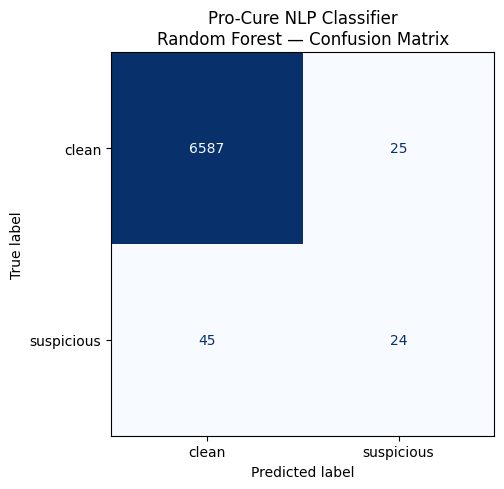


  True Positives  (correctly flagged suspicious): 24
  False Negatives (missed suspicious):            45
  False Positives (wrongly flagged clean):        25
  True Negatives  (correctly passed clean):       6587


In [8]:
# Pick best model by test F1 on suspicious class
best_name = max(results, key=lambda n: results[n]["report"]["suspicious"]["f1-score"])
best = results[best_name]

print(f"Best model: {best_name}\n")
print(classification_report(
    y_test, best["y_pred"],
    target_names=["clean (0)", "suspicious (1)"]
))

# Confusion matrix
cm = confusion_matrix(y_test, best["y_pred"])
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["clean", "suspicious"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Pro-Cure NLP Classifier\n{best_name} — Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "nlp_confusion_matrix.png"), dpi=150)
plt.show()
print(f"\n  True Positives  (correctly flagged suspicious): {cm[1,1]}")
print(f"  False Negatives (missed suspicious):            {cm[1,0]}")
print(f"  False Positives (wrongly flagged clean):        {cm[0,1]}")
print(f"  True Negatives  (correctly passed clean):       {cm[0,0]}")


## 8. Most predictive terms

Which words and phrases most strongly predict a suspicious tender?
This is the linguistic fingerprint of corruption in SA government procurement.


In [9]:
# Extract feature importance from Logistic Regression coefficients
lr_model = results["Logistic Regression"]["model"]
feature_names = tfidf.get_feature_names_out()
coefs = lr_model.coef_[0]

# Top features for suspicious class (positive coefficients)
top_suspicious_idx = np.argsort(coefs)[::-1][:25]
top_clean_idx      = np.argsort(coefs)[:25]

print("Top 25 terms predicting SUSPICIOUS tender:")
print("-" * 55)
for idx in top_suspicious_idx:
    print(f"  {coefs[idx]:>+8.3f}  {feature_names[idx]}")

print("\nTop 25 terms predicting CLEAN (competitive) tender:")
print("-" * 55)
for idx in top_clean_idx:
    print(f"  {coefs[idx]:>+8.3f}  {feature_names[idx]}")


Top 25 terms predicting SUSPICIOUS tender:
-------------------------------------------------------
   +10.989  deviation
    +9.400  variation
    +7.783  sita
    +6.605  subscription
    +6.270  warranty
    +5.227  sanitation programme
    +5.113  by
    +5.059  of trade
    +4.791  for limpopo
    +4.685  point
    +4.605  oem
    +4.530  category
    +4.521  operations
    +4.481  units
    +4.469  remote
    +4.352  quantity
    +4.306  through
    +4.245  housing units
    +4.218  till
    +4.203  the period
    +3.987  drawing
    +3.952  photovoltaic
    +3.853  licenses for
    +3.803  service for
    +3.795  purposes

Top 25 terms predicting CLEAN (competitive) tender:
-------------------------------------------------------
    -3.451  services to
    -3.246  building
    -3.131  infrastructure
    -2.699  quotation
    -2.678  years
    -2.604  road
    -2.601  of health
    -2.590  professional services
    -2.539  the appointment
    -2.494  facilities
    -2.480  contrac

## 9. Score all tenders — NLP risk scores

Apply the best model to all 33,689 tender descriptions.
This produces the `nlp_score` column that feeds into the Pro-Cure Risk Index.


In [10]:
# Use Logistic Regression for scoring (gives probabilities)
lr = results["Logistic Regression"]["model"]

# Score all records with a description
scored = nlp_df.copy()
scored_tfidf = tfidf.transform(scored["text_clean"])

# Probability of being suspicious (class 1)
scored["nlp_score"] = lr.predict_proba(scored_tfidf)[:, 1]
scored["nlp_label"] = lr.predict(scored_tfidf)

print(f"Scored {len(scored):,} tenders\n")

# Score distribution
print("NLP score distribution:")
for threshold, label in [(0.3, "Low risk (<0.3)"),
                          (0.5, "Medium (0.3–0.5)"),
                          (0.7, "High (0.5–0.7)"),
                          (1.1, "Very high (>0.7)")]:
    lower = threshold - 0.2 if threshold > 0.3 else 0
    count = ((scored["nlp_score"] >= lower) & (scored["nlp_score"] < threshold)).sum()
    pct = 100 * count / len(scored)
    print(f"  {label:<25} {count:>6,}  ({pct:.1f}%)")

# Top flagged tenders
print("\nTop 15 highest-scoring (most suspicious) tenders:")
print("-" * 80)
top_flagged = scored.nlargest(15, "nlp_score")[
    ["buyer_name", "supplier_name", "nlp_score",
     "tender_procurementMethod", "tender_description"]
]
for _, row in top_flagged.iterrows():
    print(f"\n  Score: {row['nlp_score']:.3f} | Method: {row['tender_procurementMethod']}")
    print(f"  Buyer: {str(row['buyer_name'])[:65]}")
    print(f"  Supplier: {str(row['supplier_name'])[:65]}")
    print(f"  Desc: {str(row['tender_description'])[:150]}")


Scored 33,402 tenders

NLP score distribution:
  Low risk (<0.3)           30,908  (92.5%)
  Medium (0.3–0.5)           1,412  (4.2%)
  High (0.5–0.7)               424  (1.3%)
  Very high (>0.7)             305  (0.9%)

Top 15 highest-scoring (most suspicious) tenders:
--------------------------------------------------------------------------------

  Score: 0.999 | Method: direct
  Buyer: COMMISSION FOR CONCILIATION MEDIATION & ARBITRATION
  Supplier: nan
  Desc: Deviation for Internal Audit Annual Membership & Subscription Fees by Institute of Internal Auditor South Africa	 as Sole Service Provider for Payment

  Score: 0.998 | Method: direct
  Buyer: COMMISSION FOR CONCILIATION MEDIATION & ARBITRATION
  Supplier: nan
  Desc: Deviation for Internal Audit for Annual Membership Fees	by Institute of Internal Auditors South Africa (IIASA) as a Sole Service Provider for	Annual P

  Score: 0.998 | Method: direct
  Buyer: COMMISSION FOR CONCILIATION MEDIATION & ARBITRATION
  Supplier: nan


## 10. Save results

In [11]:
import joblib

# Save NLP scores
nlp_scores_path = os.path.join(RESULTS_DIR, "nlp_scores.csv")
scored[["ocid", "buyer_name", "supplier_name", "tender_id",
        "tender_procurementMethod", "nlp_score", "nlp_label",
        "label", "tender_description"]].to_csv(nlp_scores_path, index=False)
print(f"✅ Saved scores: {nlp_scores_path}")

# Save model + vectorizer
model_dir = os.path.join(BASE_DIR, "models")
os.makedirs(model_dir, exist_ok=True)
joblib.dump(lr,    os.path.join(model_dir, "nlp_classifier_lr.joblib"))
joblib.dump(tfidf, os.path.join(model_dir, "nlp_tfidf_vectorizer.joblib"))
print(f"✅ Saved model:  {model_dir}/nlp_classifier_lr.joblib")
print(f"✅ Saved tfidf:  {model_dir}/nlp_tfidf_vectorizer.joblib")

# Results summary table for the Pro-Cure paper
print("\n" + "="*60)
print("  PRO-CURE NLP RESULTS TABLE (COS 760)")
print("="*60)
print(f"  {'Model':<25} {'CV F1':>6} {'Test P':>7} {'Test R':>7} {'Test F1':>8}")
print("  " + "-"*58)
for name, res in results.items():
    s = res["report"]["suspicious"]
    print(f"  {name:<25} {res['cv_f1']:>6.3f} {s['precision']:>7.3f} "
          f"{s['recall']:>7.3f} {s['f1-score']:>8.3f}")
print("="*60)
print("\nNext → notebooks/03_contract_splitting.ipynb")


✅ Saved scores: /Users/kamogelomotlhale/Documents/Passion Projects/pro-cure/pro-cure/results/nlp_scores.csv
✅ Saved model:  /Users/kamogelomotlhale/Documents/Passion Projects/pro-cure/pro-cure/models/nlp_classifier_lr.joblib
✅ Saved tfidf:  /Users/kamogelomotlhale/Documents/Passion Projects/pro-cure/pro-cure/models/nlp_tfidf_vectorizer.joblib

  PRO-CURE NLP RESULTS TABLE (COS 760)
  Model                      CV F1  Test P  Test R  Test F1
  ----------------------------------------------------------
  Logistic Regression        0.313   0.185   0.551    0.277
  Linear SVM                 0.395   0.283   0.493    0.360
  Random Forest              0.412   0.490   0.348    0.407

Next → notebooks/03_contract_splitting.ipynb


## ✅ Commit

```bash
git add notebooks/02_nlp_classifier.ipynb
git add results/nlp_scores.csv
git add results/nlp_confusion_matrix.png
git add models/
git commit -m "feat: Notebook 02 — NLP single-source classifier, TF-IDF + 3 baselines, all tenders scored"
git push
```
